# Sales Territory Analysis – Northeast Region

This project analyzes in-store sales performance for two assigned sales territories in the Northeast region:

- Maine Territory – Managed by Erbayne Middleton
- New Jersey Territory – Managed by Miami Vue

The goal of this analysis is to compare sales performance, customer activity, product category trends, and store effectiveness across both territories in order to provide marketing recommendations for the next quarter.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# In this step, I imported the Python libraries needed for my analysis. Pandas is used to load, clean, merge, and analyze the CSV files.
# Matplotlib is used to create charts. Path is used to create an output folder where my tables and visualizations will be saved.

Here i created an output folder inside my notebook to save my charts and visualisations 

In [13]:
output_folder = Path.cwd() / "capstone_outputs"
output_folder.mkdir(parents=True, exist_ok=True)

print("Output folder created at:", output_folder)

Output folder created at: C:\Users\dimit\documents\data_labs\capstone_2\capstone_outputs


Here, I loaded the `StoreSales.csv` file into a DataFrame named `store_sales`. This file contains the in-store sales transactions that will be used for my sales analysis.

In [14]:
store_sales = pd.read_csv("StoreSales.csv")
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


I loaded the `StoreDetail.csv` file into a DataFrame named `store_detail`. This file gives information about each store, including the store ID, location, state, region, and territory manager.

In [15]:
store_detail = pd.read_csv("StoreDetail.csv")
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


Here, I also loaded the `Products.csv` file into a DataFrame named `products`. This file connects each product to its product category ID.

In [16]:
products = pd.read_csv("Products.csv")
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


I loaded the `ProductCategories.csv` file into a DataFrame named `categories`. This file provides the actual product category names that match the category IDs from the products file.

In [17]:
categories = pd.read_csv("ProductCategories.csv")
categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


I loaded the `customer_list.csv` file into a DataFrame named `customers`. This file uses a pipe symbol instead of a comma as the separator, so I used `sep="|"`.

In [18]:
customers = pd.read_csv("customer_list.csv", sep="|")
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


## Cleaning Column Names

In this step, I cleaned the column names in each DataFrame. This makes the column names easier to work with by removing extra spaces and replacing spaces or dashes with underscores.

In [19]:
store_sales.columns = store_sales.columns.str.strip().str.replace(" ", "_")
store_detail.columns = store_detail.columns.str.strip().str.replace(" ", "_")
products.columns = products.columns.str.strip().str.replace(" ", "_")
categories.columns = categories.columns.str.strip().str.replace(" ", "_")
customers.columns = customers.columns.str.strip().str.replace("-", "_")

In this step, I convert the `Transaction_Date` column into a proper datetime format. Then I created a new `Month` column so I can group sales by month later in my analysis.

In [20]:
store_sales["Transaction_Date"] = pd.to_datetime(store_sales["Transaction_Date"])
store_sales["Month"] = store_sales["Transaction_Date"].dt.to_period("M").astype(str)

### Filter Assigned Territories

My assigned territories are Maine and New Jersey. This code filters the store detail data so I only see stores located in these two territories.

In [21]:
assigned_states = ["Maine", "New Jersey"]

assigned_stores = store_detail[
    store_detail["State"].isin(assigned_states)
]

assigned_stores

,Store_Location,State,Store_ID,Territory_Manager,Region,Region_Director
37,Bangor,Maine,818,Erbayne Middleton,Northeast,Michael Jarvis
38,Bar Harbor,Maine,819,Erbayne Middleton,Northeast,Michael Jarvis
39,Kennebunkport,Maine,820,Erbayne Middleton,Northeast,Michael Jarvis
40,Lewiston,Maine,821,Erbayne Middleton,Northeast,Michael Jarvis
41,Orono,Maine,822,Erbayne Middleton,Northeast,Michael Jarvis
42,South Portland,Maine,823,Erbayne Middleton,Northeast,Michael Jarvis
70,Atlantic City,New Jersey,824,Miami Vue,Northeast,Michael Jarvis
71,Bayonne,New Jersey,825,Miami Vue,Northeast,Michael Jarvis
72,Cape May,New Jersey,826,Miami Vue,Northeast,Michael Jarvis
73,Clifton,New Jersey,827,Miami Vue,Northeast,Michael Jarvis


This code saves the assigned stores table as a CSV file in my output folder. It could be used for visualisation.

In [22]:
assigned_stores.to_csv(
    output_folder / "01_assigned_territory_stores.csv",
    index=False
)

Here, I merge the sales data with the store detail data using `Store_ID`. This connects every transaction to its store, state, region, city, and territory manager.

In [23]:
sales_store = store_sales.merge(
    store_detail,
    on="Store_ID",
    how="left"
)

Here, I merge the sales and store data with the product data because they connects each transaction to the product information using the product number.

In [24]:
sales_product = sales_store.merge(
    products,
    on="Prod_Num",
    how="left"
)

I also merged the data with the product category file to adds the readable product category name to each transaction.

In [25]:
full_sales = sales_product.merge(
    categories[["CategoryID", "Category"]].drop_duplicates(),
    on="CategoryID",
    how="left"
)

Here, I merged the full sales data with the customer list. The sales file uses `RewardsID`, while the customer file uses `cust_id`, so I connected those two columns together.

In [26]:
full_sales = full_sales.merge(
    customers,
    left_on="RewardsID",
    right_on="cust_id",
    how="left"
)

After merging the data, I filtered the full sales table so it only includes transactions from Maine and New Jersey.

In [27]:
territory_sales = full_sales[
    full_sales["State"].isin(assigned_states)
]

territory_sales.head()


,Transaction_Date,Store_ID,RewardsID,Prod_Num,Sale_Amount,Month,Store_Location,State,Territory_Manager,Region,...,CategoryID,SubcategoryID,Category,cust_id,date,time,name,email,phone,sms_opt_out
95,2022-01-01,818,NaN,105321-IT,28.88,2022-01,Bangor,Maine,Erbayne Middleton,Northeast,...,120,120-cha,Technology & Accessories,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2022-01-01,821,507.0,105319-IT,30.16,2022-01,Lewiston,Maine,Erbayne Middleton,Northeast,...,120,120-cha,Technology & Accessories,507.0,2024-01-16,11:19:45,Plankton,plankton@bikinibottom.net,555-555-3106,N
97,2022-01-01,822,NaN,105431-M,24.28,2022-01,Orono,Maine,Erbayne Middleton,Northeast,...,130,130-acc,Apparel and Merchandise,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,2022-01-01,822,491.0,105432-S,6.02,2022-01,Orono,Maine,Erbayne Middleton,Northeast,...,110,110-adh,Stationery and Supplies,491.0,2023-05-02,13:59:15,Harry Crane,harry@sterlingcooper.com,212-555-2910,N
99,2022-01-01,823,280.0,105433-M,32.64,2022-01,South Portland,Maine,Erbayne Middleton,Northeast,...,130,130-hat,Apparel and Merchandise,280.0,2023-08-09,09:05:15,Cal Abar,cal@keenecounty.police,918-555-2105,Y


This saves the cleaned and merged sales data for Maine and New Jersey. This table is useful because it contains all the information I need for the rest of my analysis.

In [28]:
territory_sales.to_csv(
    output_folder / "02_full_merged_territory_sales.csv",
    index=False
)

# Core Marketing Analysis

## Question 1: Territory Managers and Assigned Stores

This question asks who manages each assigned territory and which stores belong to each territory. I answer this by selecting the state, territory manager, store ID, store location, and region from the assigned stores table.

In [29]:
territory_manager_table = assigned_stores[
    ["State", "Territory_Manager", "Store_ID", "Store_Location", "Region"]
].sort_values(["State", "Store_ID"])

territory_manager_table

,State,Territory_Manager,Store_ID,Store_Location,Region
37,Maine,Erbayne Middleton,818,Bangor,Northeast
38,Maine,Erbayne Middleton,819,Bar Harbor,Northeast
39,Maine,Erbayne Middleton,820,Kennebunkport,Northeast
40,Maine,Erbayne Middleton,821,Lewiston,Northeast
41,Maine,Erbayne Middleton,822,Orono,Northeast
42,Maine,Erbayne Middleton,823,South Portland,Northeast
70,New Jersey,Miami Vue,824,Atlantic City,Northeast
71,New Jersey,Miami Vue,825,Bayonne,Northeast
72,New Jersey,Miami Vue,826,Cape May,Northeast
73,New Jersey,Miami Vue,827,Clifton,Northeast


This code saves the territory manager and assigned store table as a CSV file.

In [30]:
territory_manager_table.to_csv(
    output_folder / "03_territory_managers_and_stores.csv",
    index=False
)

## Question 2: Monthly Total Revenue by Territory

This question asks for monthly total revenue for in-store sales in Maine and New Jersey. I group the sales by state and month, then add up the `Sale_Amount` values.

In [31]:
monthly_revenue = territory_sales.groupby(
    ["State", "Month"],
    as_index=False
)["Sale_Amount"].sum()

monthly_revenue = monthly_revenue.rename(
    columns={"Sale_Amount": "Monthly_Total_Revenue"}
)

monthly_revenue

,State,Month,Monthly_Total_Revenue
0,Maine,2022-01,15700.31
1,Maine,2022-02,21008.29
2,Maine,2022-03,23173.23
3,Maine,2022-04,20169.19
4,Maine,2022-05,22631.11
...,...,...,...
91,New Jersey,2025-08,151923.99
92,New Jersey,2025-09,163449.78
93,New Jersey,2025-10,250830.46
94,New Jersey,2025-11,146953.33


This code saves the monthly revenue table as a CSV file. This table shows revenue trends over time for both territories.

In [32]:
monthly_revenue.to_csv(
    output_folder / "04_monthly_revenue_by_territory.csv",
    index=False
)

This line chart compares Maine and New Jersey monthly revenue over time. A line chart is useful here because it shows changes and trends from month to month.

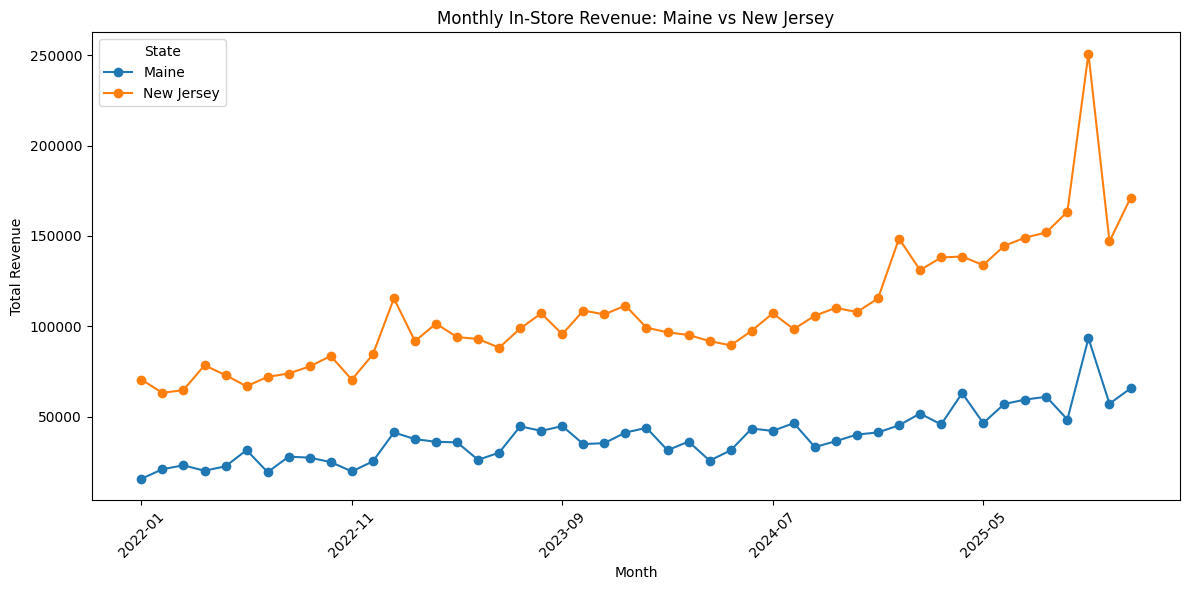

In [33]:
monthly_pivot = monthly_revenue.pivot(
    index="Month",
    columns="State",
    values="Monthly_Total_Revenue"
)

monthly_pivot.plot(kind="line", marker="o", figsize=(12, 6))

plt.title("Monthly In-Store Revenue: Maine vs New Jersey")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_folder / "04_monthly_revenue_trend_maine_vs_new_jersey.png")
plt.show()

## Question 3: Store Sales Performance Ranking

This question asks how each store performs in its territory. I group the data by state, store ID, and store location, then calculate total revenue for each store. After that, I rank the stores inside each state from highest revenue to lowest revenue.

In [34]:
store_ranking = territory_sales.groupby(
    ["State", "Store_ID", "Store_Location"],
    as_index=False
)["Sale_Amount"].sum()

store_ranking = store_ranking.rename(
    columns={"Sale_Amount": "Total_Store_Revenue"}
)

store_ranking["Rank_in_State"] = store_ranking.groupby("State")[
    "Total_Store_Revenue"
].rank(ascending=False, method="dense")

store_ranking = store_ranking.sort_values(
    ["State", "Rank_in_State"]
)

store_ranking

,State,Store_ID,Store_Location,Total_Store_Revenue,Rank_in_State
5,Maine,823,South Portland,332611.76,1.0
4,Maine,822,Orono,330505.47,2.0
2,Maine,820,Kennebunkport,321998.55,3.0
3,Maine,821,Lewiston,303761.91,4.0
0,Maine,818,Bangor,300919.98,5.0
1,Maine,819,Bar Harbor,287452.08,6.0
17,New Jersey,835,Newark,623163.53,1.0
20,New Jersey,838,Trenton,597565.68,2.0
12,New Jersey,830,Hoboken,316775.48,3.0
6,New Jersey,824,Atlantic City,314513.77,4.0


This code saves the store ranking table as a CSV file. This makes it easier to see the top-performing and lowest-performing stores.

In [35]:
store_ranking.to_csv(
    output_folder / "05_store_performance_ranking.csv",
    index=False
)

This bar chart compares total revenue by store. A bar chart works well here because I am comparing different store locations against each other.

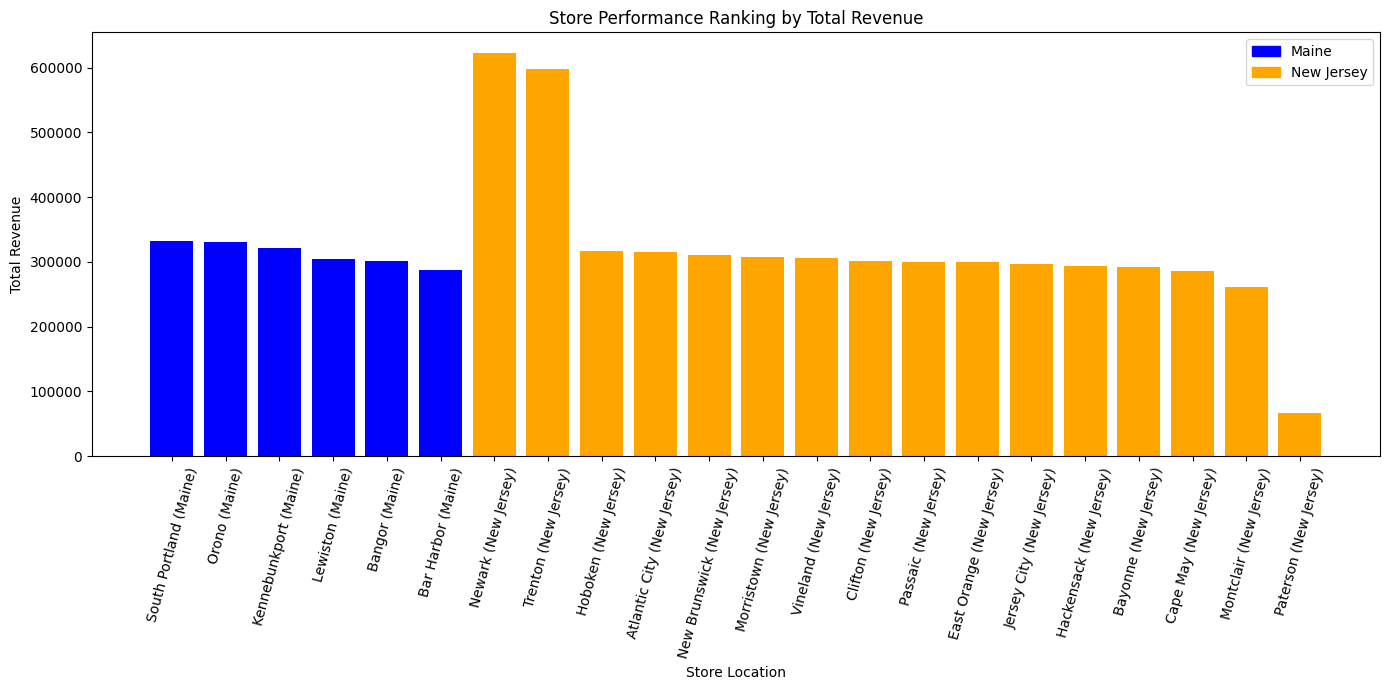

In [37]:
plt.figure(figsize=(14, 7))

# Create colors based on state
colors = store_ranking["State"].map({
    "Maine": "blue",
    "New Jersey": "orange"
})

# Create bar chart
plt.bar(
    store_ranking["Store_Location"] + " (" + store_ranking["State"] + ")",
    store_ranking["Total_Store_Revenue"],
    color=colors
)

plt.title("Store Performance Ranking by Total Revenue")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")

plt.xticks(rotation=75)

# Create custom legend
import matplotlib.patches as mpatches

maine_patch = mpatches.Patch(color="blue", label="Maine")
newjersey_patch = mpatches.Patch(color="orange", label="New Jersey")

plt.legend(handles=[maine_patch, newjersey_patch])

plt.tight_layout()

plt.savefig(output_folder / "05_store_performance_ranking.png")

plt.show()

## Create Store Ranking Bar Chart

This chart compares total store revenue between Maine and New Jersey.

I used:
- Blue bars for Maine
- Orange bars for New Jersey

I created a custom legend so the territories can be easily identified. A bar chart works well here because it makes comparing store performance easier across locations.

## Question 4: Top Customers in Each Territory

This question asks who the top customers are in each sales territory. I remove rows without a rewards ID, then group by state, rewards ID, customer name, and email. After that, I total each customer’s sales amount and rank them by territory.

In [38]:
top_customers = territory_sales.dropna(subset=["RewardsID"]).groupby(
    ["State", "RewardsID", "name", "email"],
    as_index=False
)["Sale_Amount"].sum()

top_customers = top_customers.rename(
    columns={"Sale_Amount": "Total_Customer_Revenue"}
)

top_customers["Customer_Rank"] = top_customers.groupby("State")[
    "Total_Customer_Revenue"
].rank(ascending=False, method="dense")

top_customers = top_customers.sort_values(
    ["State", "Customer_Rank"]
)

top_customers.head(20)

,State,RewardsID,name,email,Total_Customer_Revenue,Customer_Rank
384,Maine,421.0,Rosita,rosita@sesamestreet.org,3637.75,1.0
80,Maine,89.0,Karen Walker,karen@willandgrace.nyc,3362.83,2.0
313,Maine,345.0,Maddy Perez,maddy@easthighland.high,2706.42,3.0
8,Maine,9.0,Mike H.,mike@centralperk.coffee,2695.22,4.0
186,Maine,208.0,Philip Banks,unclephil@banksresidence.la,2662.84,5.0
437,Maine,478.0,AJ Soprano,aj@northjersey.net,2574.08,6.0
88,Maine,99.0,Trent Lane,trent@lawndale.high,2558.21,7.0
320,Maine,353.0,Laura Palmer,laura@twinpeaks.wa,2488.19,8.0
325,Maine,358.0,James Hurley,james@twinpeaks.wa,2482.78,9.0
164,Maine,185.0,Nipsey,nipsey@wzhup.det,2112.13,10.0


This code saves the top customer table as a CSV file. This can help marketing identify valuable rewards members for targeted promotions.

In [39]:
top_customers.to_csv(
    output_folder / "06_top_customers_by_territory.csv",
    index=False
)

## Question 5: Number of Transactions Per Month by Product Category

This question looks at how often each product category was purchased each month in each territory. I group by state, month, and category, then count the number of transactions.

In [40]:
monthly_category_transactions = territory_sales.groupby(
    ["State", "Month", "Category"],
    as_index=False
).size()

monthly_category_transactions = monthly_category_transactions.rename(
    columns={"size": "Number_of_Transactions"}
)

monthly_category_transactions

,State,Month,Category,Number_of_Transactions
0,Maine,2022-01,Apparel and Merchandise,30
1,Maine,2022-01,Art Supplies,31
2,Maine,2022-01,Books (General),12
3,Maine,2022-01,Stationery and Supplies,29
4,Maine,2022-01,Technology & Accessories,35
...,...,...,...,...
571,New Jersey,2025-12,Art Supplies,189
572,New Jersey,2025-12,Books (General),78
573,New Jersey,2025-12,Stationery and Supplies,227
574,New Jersey,2025-12,Technology & Accessories,281


This code saves the transaction count table as a CSV file. This table helps show which product categories customers buy most often.

In [41]:
monthly_category_transactions.to_csv(
    output_folder / "07_monthly_transactions_by_category.csv",
    index=False
)

## Question 6: Total Sales Revenue Per Month by Product Category

This question looks at how much revenue each product category generated each month. I group by state, month, and category, then add up the sales amount.

In [42]:
monthly_category_revenue = territory_sales.groupby(
    ["State", "Month", "Category"],
    as_index=False
)["Sale_Amount"].sum()

monthly_category_revenue = monthly_category_revenue.rename(
    columns={"Sale_Amount": "Monthly_Category_Revenue"}
)

monthly_category_revenue

,State,Month,Category,Monthly_Category_Revenue
0,Maine,2022-01,Apparel and Merchandise,958.97
1,Maine,2022-01,Art Supplies,857.61
2,Maine,2022-01,Books (General),370.52
3,Maine,2022-01,Stationery and Supplies,232.05
4,Maine,2022-01,Technology & Accessories,9007.64
...,...,...,...,...
571,New Jersey,2025-12,Art Supplies,6384.20
572,New Jersey,2025-12,Books (General),1932.69
573,New Jersey,2025-12,Stationery and Supplies,2307.96
574,New Jersey,2025-12,Technology & Accessories,131024.14


This code saves the monthly category revenue table as a CSV file. This helps compare category sales performance over time.

In [43]:
monthly_category_revenue.to_csv(
    output_folder / "08_monthly_revenue_by_category.csv",
    index=False
)

This table summarizes total revenue by product category and territory. This makes it easier to identify the strongest and weakest product categories overall.

In [44]:
category_total_revenue = territory_sales.groupby(
    ["State", "Category"],
    as_index=False
)["Sale_Amount"].sum()

category_total_revenue = category_total_revenue.rename(
    columns={"Sale_Amount": "Total_Category_Revenue"}
)

category_total_revenue

,State,Category,Total_Category_Revenue
0,Maine,Apparel and Merchandise,80611.53
1,Maine,Art Supplies,70570.15
2,Maine,Books (General),29730.25
3,Maine,Stationery and Supplies,27717.10
4,Maine,Technology & Accessories,1359289.84
5,Maine,Textbooks,309330.88
6,New Jersey,Apparel and Merchandise,237281.41
7,New Jersey,Art Supplies,197096.50
8,New Jersey,Books (General),90319.41
9,New Jersey,Stationery and Supplies,83170.46


This code saves the category revenue summary table as a CSV file.

In [45]:
category_total_revenue.to_csv(
    output_folder / "09_total_category_revenue_by_territory.csv",
    index=False
)

This bar chart compares total revenue by product category and territory. This helps show which categories are bringing in the most money.

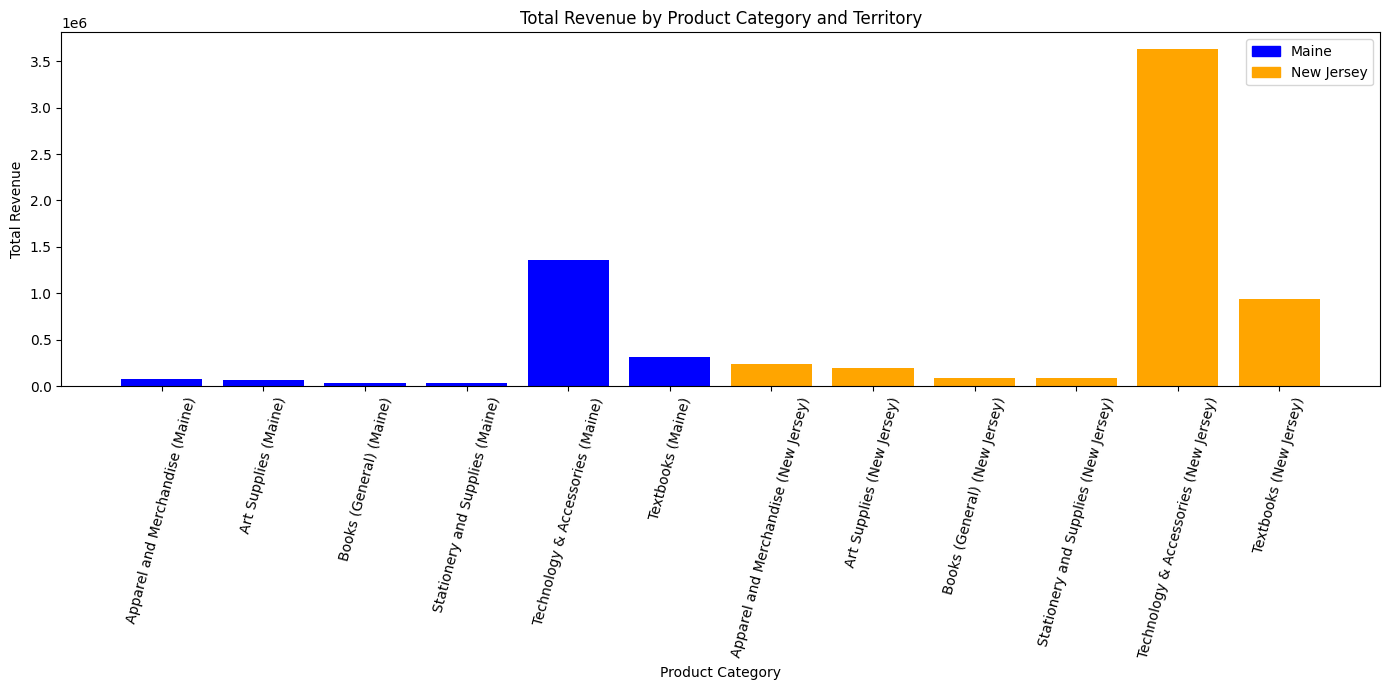

In [51]:
plt.figure(figsize=(14, 7))

# Create colors based on state
colors = category_total_revenue["State"].map({
    "Maine": "blue",
    "New Jersey": "orange"
})

plt.bar(
    category_total_revenue["Category"] + " (" + category_total_revenue["State"] + ")",
    category_total_revenue["Total_Category_Revenue"],
    color=colors
)

plt.title("Total Revenue by Product Category and Territory")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=75)

# Create custom legend
import matplotlib.patches as mpatches

maine_patch = mpatches.Patch(color="blue", label="Maine")
newjersey_patch = mpatches.Patch(color="orange", label="New Jersey")

plt.legend(handles=[maine_patch, newjersey_patch])

plt.tight_layout()

plt.savefig(output_folder / "09_total_revenue_by_category_and_territory.png")
plt.show()

## Create Product Category Revenue Bar Chart

This chart compares total revenue by product category for Maine and New Jersey.

I used:
- Blue bars for Maine
- Orange bars for New Jersey

This makes it easier to tell which product categories belong to each territory.

This table counts total transactions by product category and territory. This helps show product popularity based on how often customers buy items in each category.

In [52]:
category_transaction_summary = territory_sales.groupby(
    ["State", "Category"],
    as_index=False
).size()

category_transaction_summary = category_transaction_summary.rename(
    columns={"size": "Total_Transactions"}
)

category_transaction_summary = category_transaction_summary.sort_values(
    ["State", "Total_Transactions"],
    ascending=[True, False]
)

category_transaction_summary

,State,Category,Total_Transactions
4,Maine,Technology & Accessories,2848
3,Maine,Stationery and Supplies,2763
0,Maine,Apparel and Merchandise,2552
1,Maine,Art Supplies,2230
5,Maine,Textbooks,1800
2,Maine,Books (General),1050
9,New Jersey,Stationery and Supplies,8265
10,New Jersey,Technology & Accessories,7883
6,New Jersey,Apparel and Merchandise,7353
7,New Jersey,Art Supplies,6129


This code saves the product category transaction summary as a CSV file.

In [53]:
category_transaction_summary.to_csv(
    output_folder / "10_category_transaction_summary.csv",
    index=False
)

This bar chart compares the number of transactions by product category and territory. It helps show which categories customers are buying most often.

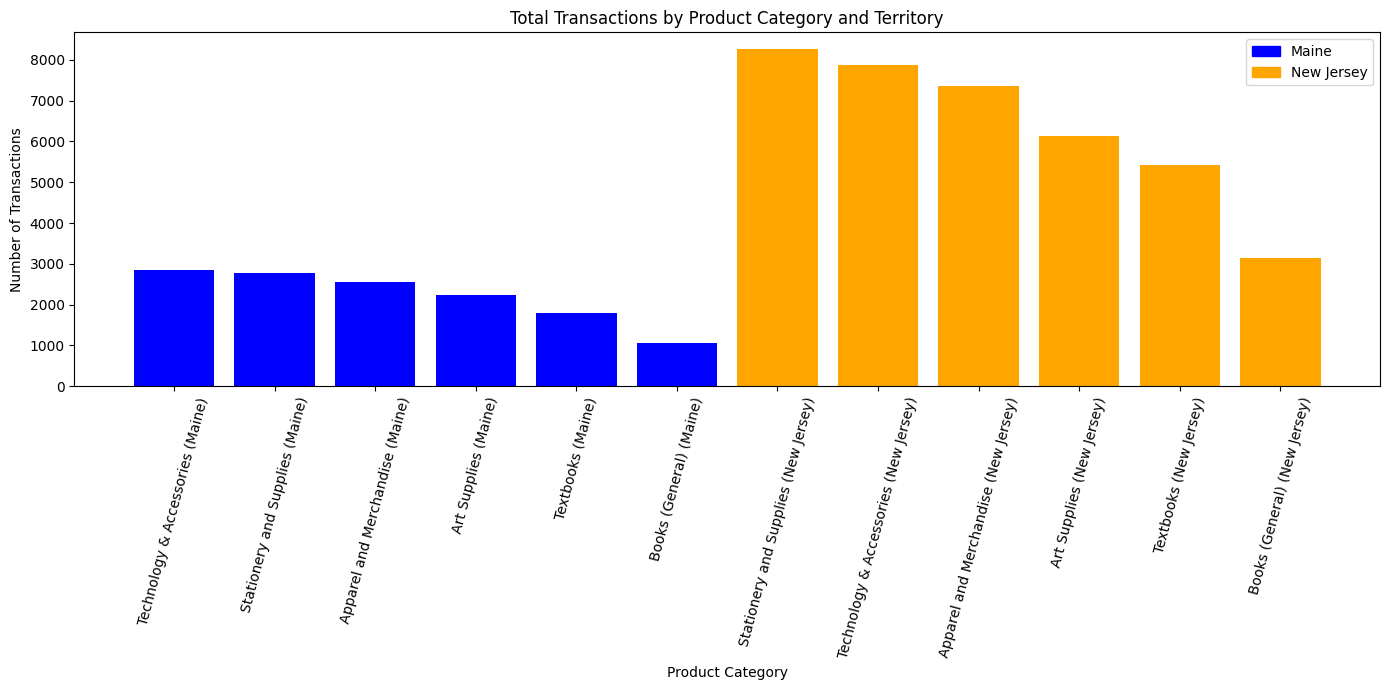

In [54]:
plt.figure(figsize=(14, 7))

# Create colors based on state
colors = category_transaction_summary["State"].map({
    "Maine": "blue",
    "New Jersey": "orange"
})

plt.bar(
    category_transaction_summary["Category"] + " (" + category_transaction_summary["State"] + ")",
    category_transaction_summary["Total_Transactions"],
    color=colors
)

plt.title("Total Transactions by Product Category and Territory")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=75)

# Create custom legend
import matplotlib.patches as mpatches

maine_patch = mpatches.Patch(color="blue", label="Maine")
newjersey_patch = mpatches.Patch(color="orange", label="New Jersey")

plt.legend(handles=[maine_patch, newjersey_patch])

plt.tight_layout()

plt.savefig(output_folder / "10_transactions_by_category_and_territory.png")
plt.show()

# Final Dashboard

This dashboard brings together the main findings from the sales territory analysis. It summarizes total revenue, number of transactions, store performance, and product category performance for Maine and New Jersey.

In [55]:
# Create dashboard summary numbers
dashboard_summary = territory_sales.groupby("State").agg(
    Total_Revenue=("Sale_Amount", "sum"),
    Total_Transactions=("Sale_Amount", "count"),
    Average_Transaction=("Sale_Amount", "mean"),
    Number_of_Stores=("Store_ID", "nunique")
).reset_index()

dashboard_summary

,State,Total_Revenue,Total_Transactions,Average_Transaction,Number_of_Stores
0,Maine,1877249.75,13243,141.754115,6
1,New Jersey,5175405.87,38195,135.499565,16


## Dashboard Summary Table

This table gives a high-level comparison between Maine and New Jersey. It shows total revenue, total transactions, average transaction size, and number of stores in each territory.

In [56]:
dashboard_summary.to_csv(
    output_folder / "11_dashboard_summary_table.csv",
    index=False
)

## Dashboard Visualization

This dashboard includes four charts:
1. Total revenue by territory
2. Total transactions by territory
3. Top stores by revenue
4. Top product categories by revenue

These visuals help summarize the main findings from the full analysis

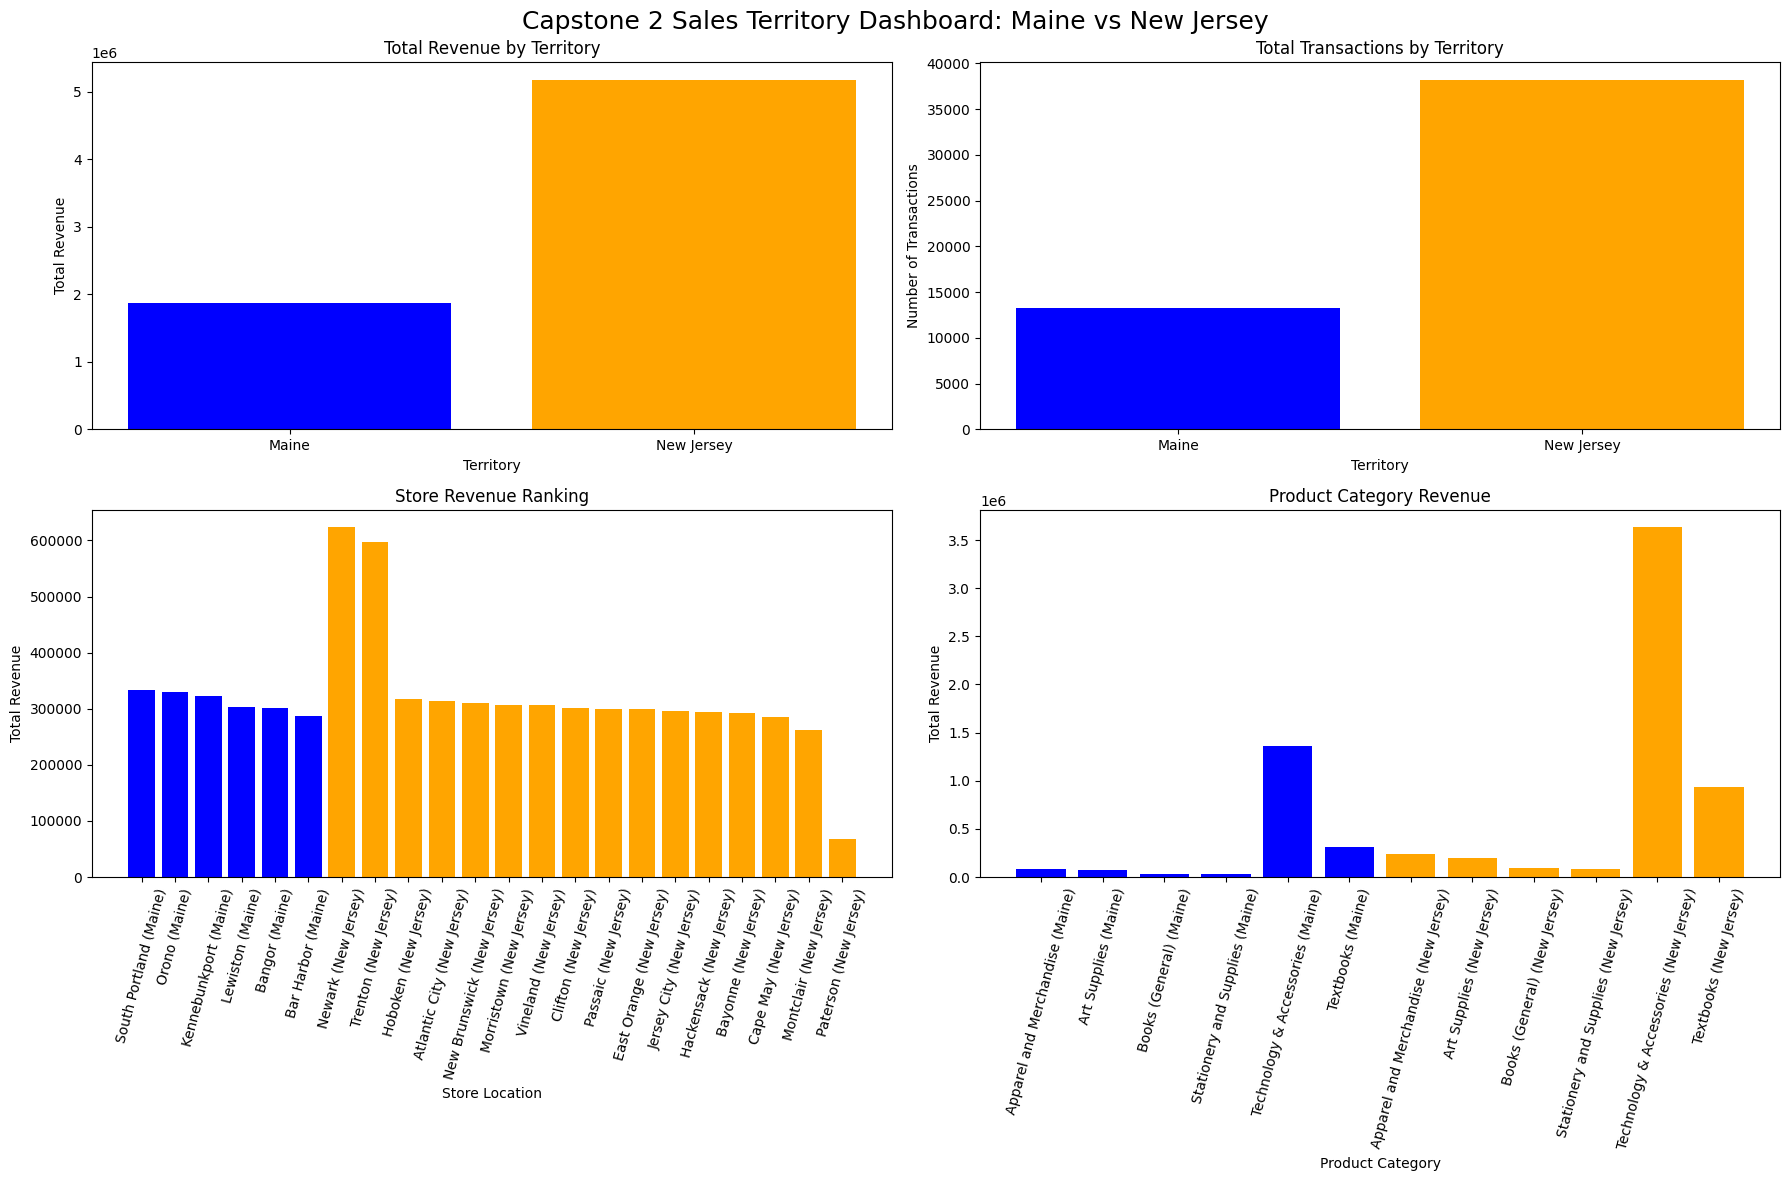

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

state_colors = {
    "Maine": "blue",
    "New Jersey": "orange"
}

# Chart 1: Total Revenue by Territory
axes[0, 0].bar(
    dashboard_summary["State"],
    dashboard_summary["Total_Revenue"],
    color=dashboard_summary["State"].map(state_colors)
)

axes[0, 0].set_title("Total Revenue by Territory")
axes[0, 0].set_xlabel("Territory")
axes[0, 0].set_ylabel("Total Revenue")


# Chart 2: Total Transactions by Territory
axes[0, 1].bar(
    dashboard_summary["State"],
    dashboard_summary["Total_Transactions"],
    color=dashboard_summary["State"].map(state_colors)
)

axes[0, 1].set_title("Total Transactions by Territory")
axes[0, 1].set_xlabel("Territory")
axes[0, 1].set_ylabel("Number of Transactions")


# Chart 3: Store Performance
store_colors = store_ranking["State"].map(state_colors)

axes[1, 0].bar(
    store_ranking["Store_Location"] + " (" + store_ranking["State"] + ")",
    store_ranking["Total_Store_Revenue"],
    color=store_colors
)

axes[1, 0].set_title("Store Revenue Ranking")
axes[1, 0].set_xlabel("Store Location")
axes[1, 0].set_ylabel("Total Revenue")
axes[1, 0].tick_params(axis="x", rotation=75)


# Chart 4: Category Revenue
category_colors = category_total_revenue["State"].map(state_colors)

axes[1, 1].bar(
    category_total_revenue["Category"] + " (" + category_total_revenue["State"] + ")",
    category_total_revenue["Total_Category_Revenue"],
    color=category_colors
)

axes[1, 1].set_title("Product Category Revenue")
axes[1, 1].set_xlabel("Product Category")
axes[1, 1].set_ylabel("Total Revenue")
axes[1, 1].tick_params(axis="x", rotation=75)


# Dashboard title
fig.suptitle(
    "Capstone 2 Sales Territory Dashboard: Maine vs New Jersey",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    output_folder / "11_final_sales_dashboard_maine_vs_new_jersey.png"
)

plt.show()

## Dashboard Explanation

This dashboard gives a final overview of the analysis. Maine is shown in blue and New Jersey is shown in orange so the two territories are easy to compare.

The first chart compares total revenue by territory. The second chart compares the total number of transactions. The third chart ranks store performance by total revenue. The fourth chart compares revenue by product category.

This dashboard helps support my final recommendation because it brings the most important sales patterns into one view. It shows which territory generated more revenue, which stores performed best, and which product categories brought in the most sales.

## Marketing Recommendation

Based on my analysis, I recommend that the marketing team focus next quarter on the stores and product categories that are performing below the territory average.

New Jersey may have more sales activity depending on the number of stores and customers, so I would not only compare Maine and New Jersey by total revenue. Instead, I would also look closely at store-level performance and product category performance.

The top-performing stores can show what is already working well. Marketing can study those stores and apply similar strategies to weaker stores. This could include better product placement, stronger promotions, improved inventory planning, or targeted local advertising.

For product categories, categories with high transaction counts show what customers are already interested in. Categories with lower sales or fewer transactions may need more visibility, discounts, bundles, or seasonal promotions.

My main recommendation is to:
1. Focus marketing support on the lowest-performing stores.
2. Promote weaker product categories with growth potential.
3. Use top rewards customers for targeted campaigns.
4. Learn from the highest-performing stores and repeat those strategies in weaker locations.